In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import uproot
import awkward as ak
import collections

In [2]:
#load Sim_D2ODetector013.root
path = "/home/genli/g4d2o-topcylindricaldet/data/Sim_D2ODetector017.root"
file = uproot.open(path)
# Check the keys in the ROOT file
print(file.keys())

Sim_Tree = file["Sim_Tree"]
# Check the branches in the tree
print(Sim_Tree.keys())
event_data = Sim_Tree["eventData"]
print(event_data.keys())

['beamOn.dat;1', 'Setup_Tree;1', 'Sim_Tree;1', 'histos;1', 'histos/pmtHits;1', 'histos/pmtNumVsTime;1', 'histos/photonEnergy;1', 'histos/photonsPerEvent;1', 'pmtPositions;1', 'pmtPositions/pmtPosX;1', 'pmtPositions/pmtPosY;1', 'pmtPositions/pmtPosZ;1']
['eventData', 'eventData/TObject', 'eventData/TObject/fUniqueID', 'eventData/TObject/fBits', 'eventData/eventNumber', 'eventData/direction0', 'eventData/position0', 'eventData/vol0', 'eventData/sourceParticleEnergy', 'eventData/sourceParticlePDG', 'eventData/numHits', 'eventData/numHitsArea', 'eventData/muVetoEnergy[12]', 'eventData/pmtHits', 'eventData/pmtHits/pmtHits.fUniqueID', 'eventData/pmtHits/pmtHits.fBits', 'eventData/pmtHits/pmtHits.pmtNum', 'eventData/pmtHits/pmtHits.eventTime', 'eventData/pmtHits/pmtHits.photonEnergy', 'eventData/pmtHits/pmtHits.parentType', 'eventData/areaPMTHits', 'eventData/areaPMTHits/areaPMTHits.fUniqueID', 'eventData/areaPMTHits/areaPMTHits.fBits', 'eventData/areaPMTHits/areaPMTHits.pmtNum', 'eventData/a

In [3]:
# Show all branches in the eventData
event_data.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
eventData            | simEvent                 | AsGroup(<TBranchElement 'event
TObject              | (group of fUniqueID:u... | AsGroup(<TBranchElement 'TO...
TObject/fUniqueID    | uint32_t                 | AsDtype('>u4')
TObject/fBits        | uint32_t                 | AsDtype('>u4')
eventNumber          | int32_t                  | AsDtype('>i4')
direction0           | TVector3                 | AsStridedObjects(Model_TVec...
position0            | TVector3                 | AsStridedObjects(Model_TVec...
vol0                 | int32_t                  | AsDtype('>i4')
sourceParticleEnergy | double                   | AsDtype('>f8')
sourceParticlePDG    | int32_t                  | AsDtype('>i4')
numHits              | int32_t                  | AsDtype('>i4')
numHitsArea          | int32_t                  | AsDtype('

In [4]:
parent_PMTevent = event_data["pmtHits/pmtHits.parentType"].array()
mask = ak.num(parent_PMTevent) > 0
parent_PMTevent_nonempty = parent_PMTevent[mask]

print("kept", ak.sum(mask), "events out of", len(parent_PMTevent))
parent_type_map = {
    1: "Muon",
    2: "Michel Electron",
    3: "Other Electron",
    4: "Other",
    5: "Neutron Capture",
    6: "Other Gamma",
    7: "Delta Ray",
    8: "Primary Electron",
    9: "Radioactive Decay",
    10: "Neutron Inelastic",
    11: "Cosmic Ray Gamma"
}

# Example usage to print readable labels
for event_types in parent_PMTevent_nonempty[:10]:
    print([parent_type_map.get(t, "Unknown") for t in event_types])

kept 271 events out of 50000
['Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Delta Ray', 'Delta Ray', 'Delta Ray', 'Delta Ray', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon'

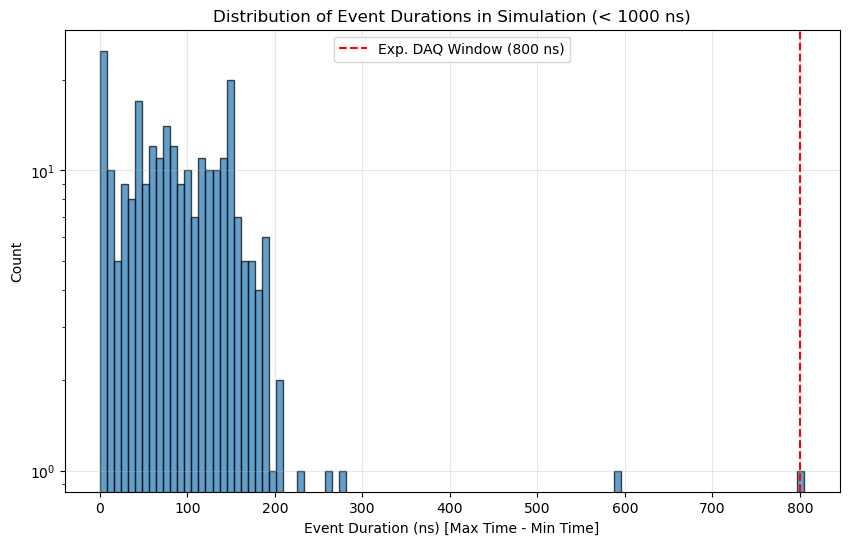

Total events with hits: 271
Events < 1000 ns: 255
Mean duration (<1000ns): 93.91 ns
Median duration (<1000ns): 84.13 ns
Max duration (<1000ns): 805.13 ns
Events longer than 800 ns (in filtered): 1 (0.39%)


/raid1/genli/conda/miniconda3/envs/py311/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


In [5]:
# Calculate event duration (max time - min time) for each event
pmt_hit_times = event_data["pmtHits/pmtHits.eventTime"].array()

# Filter events that have at least 1 hit
mask_valid = ak.num(pmt_hit_times) > 0
valid_times = pmt_hit_times[mask_valid]

if len(valid_times) > 0:
    # Calculate min and max time for each event
    t_min = ak.min(valid_times, axis=1)
    t_max = ak.max(valid_times, axis=1)
    durations = t_max - t_min

    # Apply mask: keep only events with duration < 1000 ns
    mask_time = durations < 1000
    durations_filtered = durations[mask_time]

    # Plot the distribution
    plt.figure(figsize=(10, 6))
    plt.hist(durations_filtered, bins=100, alpha=0.7, edgecolor='black')
    plt.xlabel('Event Duration (ns) [Max Time - Min Time]')
    plt.ylabel('Count')
    plt.title('Distribution of Event Durations in Simulation (< 1000 ns)')
    plt.grid(True, alpha=0.3)
    
    # Add a line for the experimental DAQ window
    plt.axvline(x=800, color='r', linestyle='--', label='Exp. DAQ Window (800 ns)')
    plt.legend()
    plt.yscale('log') # Log scale is often useful for time distributions
    plt.show()

    print(f"Total events with hits: {len(durations)}")
    print(f"Events < 1000 ns: {len(durations_filtered)}")
    print(f"Mean duration (<1000ns): {np.mean(durations_filtered):.2f} ns")
    print(f"Median duration (<1000ns): {np.median(durations_filtered):.2f} ns")
    print(f"Max duration (<1000ns): {np.max(durations_filtered):.2f} ns")
    print(f"Events longer than 800 ns (in filtered): {np.sum(durations_filtered > 800)} ({np.sum(durations_filtered > 800)/len(durations_filtered)*100:.2f}%)")
else:
    print("No events with hits found.")

In [6]:
# Analyze events with duration > 800 ns
print(f"\n{'='*80}")
print("Analysis of Long Events (> 800 ns)")
print(f"{'='*80}\n")

# Ensure parent_type_map is available
parent_type_map = {
    1: "Muon",
    2: "Michel Electron",
    3: "Other Electron",
    4: "Other",
    5: "Neutron Capture",
    6: "Other Gamma",
    7: "Delta Ray",
    8: "Primary Electron",
    9: "Radioactive Decay",
    10: "Neutron Inelastic",
    11: "Cosmic Ray Gamma"
}

if len(valid_times) > 0:
    # Get parent types for valid events (events with hits)
    # We use the same mask_valid from previous cell logic
    all_parent_types = event_data["pmtHits/pmtHits.parentType"].array()[mask_valid]
    
    # Filter for long events
    mask_long = durations > 800
    
    long_durations = durations[mask_long]
    
    # Get original event indices
    all_indices = np.arange(len(pmt_hit_times))
    valid_indices = all_indices[mask_valid]
    long_indices = valid_indices[mask_long]
    
    num_long_events = len(long_durations)
    print(f"Found {num_long_events} events with duration > 800 ns")
    
    if num_long_events > 0:
        print("\nDetailed view of long events (Top 10 by duration):")
        
        # Sort by duration descending
        sort_idx = np.argsort(long_durations)[::-1]
        
        # Access full parent array for indexing
        full_parent_array = event_data["pmtHits/pmtHits.parentType"].array()

        for i in sort_idx[:10]:  # Show top 10
            evt_idx = long_indices[i]
            dur = long_durations[i]
            
            # Get data for this specific event
            evt_times = pmt_hit_times[evt_idx]
            evt_parents = full_parent_array[evt_idx]
            
            # Sort hits by time
            time_sort_idx = np.argsort(evt_times)
            sorted_times = evt_times[time_sort_idx]
            sorted_parents = evt_parents[time_sort_idx]
            
            print(f"Event {evt_idx} (Duration: {dur:.2f} ns, {len(sorted_times)} photons):")
            
            # Row 1: Times
            print(f"  Times: {np.array2string(np.array(sorted_times), precision=1, separator=', ', threshold=100)}")
            
            # Row 2: Parent Types (Mapped to names)
            mapped_parents = [parent_type_map.get(p, str(p)) for p in sorted_parents]
            print(f"  Types: {mapped_parents}")
            print("-" * 80)
            
    else:
        print("No events found exceeding 800 ns.")


Analysis of Long Events (> 800 ns)

Found 17 events with duration > 800 ns

Detailed view of long events (Top 10 by duration):
Event 24973 (Duration: 27788659.88 ns, 1333 photons):
  Times: [3.4e+01, 3.4e+01, 3.5e+01, ..., 2.8e+07, 2.8e+07, 2.8e+07]
  Types: ['Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Delta Ray', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Delta Ray', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', 'Muon', '

In [7]:
# Analyze the timing of "Other Electron" and new types in long events
# to see if they appear in both the prompt (Muon) and delayed (Michel) windows.

if len(valid_times) > 0 and np.sum(mask_long) > 0:
    print(f"\n{'='*80}")
    print("Timing Analysis of Electron Types in Long Events")
    print(f"{'='*80}\n")
    
    # Get indices of long events
    long_event_indices = valid_indices[mask_long]
    
    # Pick the first few long events to analyze
    for i in range(min(5, len(long_event_indices))):
        evt_idx = long_event_indices[i]
        
        # Get data
        times = pmt_hit_times[evt_idx]
        parents = full_parent_array[evt_idx]
        
        print(f"Event {evt_idx}:")
        
        # Define types to check
        types_to_check = {
            3: "Other Electron",
            5: "Neutron Capture",
            6: "Other Gamma",
            7: "Delta Ray",
            8: "Primary Electron",
            9: "Radioactive Decay",
            10: "Neutron Inelastic",
            11: "Cosmic Ray Gamma"
        }
        
        for type_code, type_name in types_to_check.items():
            mask_type = parents == type_code
            times_type = times[mask_type]
            
            if len(times_type) > 0:
                # Check if they are early or late
                early = times_type[times_type < 200] 
                late = times_type[times_type > 200]  
                
                print(f"  Type {type_code} ({type_name}): {len(times_type)} total")
                if len(early) > 0:
                    print(f"    Early (<200ns): {len(early)} hits (Range: {np.min(early):.1f}-{np.max(early):.1f} ns)")
                if len(late) > 0:
                    print(f"    Late  (>200ns): {len(late)} hits (Range: {np.min(late):.1f}-{np.max(late):.1f} ns)")
            else:
                # Only print if we expect it might be there (e.g. for Type 3 which was common before)
                if type_code == 3:
                     print(f"  Type {type_code} ({type_name}): None")

        # Check Type 2 (Michel) timing for comparison
        mask_type2 = parents == 2
        times_type2 = times[mask_type2]
        if len(times_type2) > 0:
             print(f"  Type 2 (Michel):   {len(times_type2)} hits (Range: {np.min(times_type2):.1f}-{np.max(times_type2):.1f} ns)")
        else:
             print("  Type 2 (Michel):   None")
        
        print("-" * 40)


Timing Analysis of Electron Types in Long Events

Event 5373:
  Type 3 (Other Electron): 18 total
    Late  (>200ns): 18 hits (Range: 3324.6-3356.8 ns)
  Type 7 (Delta Ray): 17 total
    Early (<200ns): 1 hits (Range: 61.2-61.2 ns)
    Late  (>200ns): 16 hits (Range: 3324.3-3361.8 ns)
  Type 2 (Michel):   105 hits (Range: 3324.6-3426.0 ns)
----------------------------------------
Event 5803:
  Type 3 (Other Electron): None
  Type 7 (Delta Ray): 104 total
    Early (<200ns): 40 hits (Range: 23.3-81.1 ns)
    Late  (>200ns): 64 hits (Range: 3797.5-3904.3 ns)
  Type 2 (Michel):   277 hits (Range: 3796.8-3914.9 ns)
----------------------------------------
Event 7203:
  Type 3 (Other Electron): 33 total
    Early (<200ns): 29 hits (Range: 49.8-100.3 ns)
    Late  (>200ns): 4 hits (Range: 177188.2-177203.7 ns)
  Type 2 (Michel):   None
----------------------------------------
Event 8363:
  Type 3 (Other Electron): 23 total
    Late  (>200ns): 23 hits (Range: 3511.5-302353.8 ns)
  Type 7 (De


Analysis of Events with > 1 PMT Hit

Total events: 50000
Events with > 1 PMT hit: 252


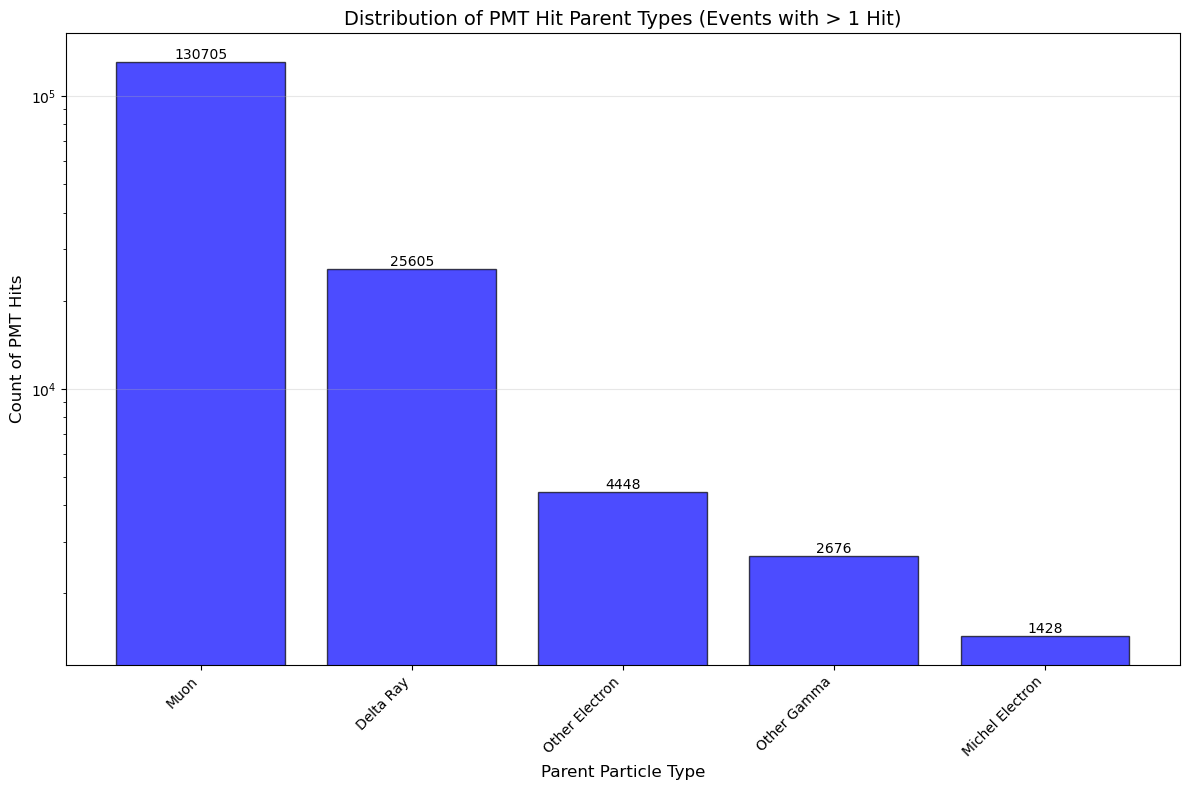


Parent Type Breakdown (Events > 1 hit):
  Muon: 130705 hits (79.3%)
  Delta Ray: 25605 hits (15.5%)
  Other Electron: 4448 hits (2.7%)
  Other Gamma: 2676 hits (1.6%)
  Michel Electron: 1428 hits (0.9%)


In [8]:
# Analyze events with > 1 PMT hit
print(f"\n{'='*80}")
print("Analysis of Events with > 1 PMT Hit")
print(f"{'='*80}\n")

# Get parent types
all_parent_types = event_data["pmtHits/pmtHits.parentType"].array()

# Filter for events with > 1 hit
mask_gt1 = ak.num(all_parent_types) > 1
events_gt1_parents = all_parent_types[mask_gt1]

print(f"Total events: {len(all_parent_types)}")
print(f"Events with > 1 PMT hit: {len(events_gt1_parents)}")

if len(events_gt1_parents) > 0:
    # Flatten to get all hits from these events
    flat_parents = ak.flatten(events_gt1_parents)

    # Count occurrences
    counter_parents = collections.Counter(flat_parents)

    # Prepare data for plotting
    parent_codes = list(counter_parents.keys())
    parent_counts = [counter_parents[c] for c in parent_codes]
    parent_labels = [parent_type_map.get(c, f"Unknown ({c})") for c in parent_codes]

    # Sort by count descending
    sorted_indices = np.argsort(parent_counts)[::-1]
    sorted_codes = np.array(parent_codes)[sorted_indices]
    sorted_counts = np.array(parent_counts)[sorted_indices]
    sorted_labels = np.array(parent_labels)[sorted_indices]

    # Plot
    plt.figure(figsize=(12, 8))
    bars = plt.bar(range(len(sorted_labels)), sorted_counts, alpha=0.7, edgecolor='black', color='blue')

    plt.xlabel("Parent Particle Type", fontsize=12)
    plt.ylabel("Count of PMT Hits", fontsize=12)
    plt.title("Distribution of PMT Hit Parent Types (Events with > 1 Hit)", fontsize=14)
    plt.xticks(range(len(sorted_labels)), sorted_labels, rotation=45, ha='right')
    plt.yscale('log') # Log scale is useful for large disparities

    # Add count labels
    for bar, count in zip(bars, sorted_counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                str(count), ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # Print summary
    print("\nParent Type Breakdown (Events > 1 hit):")
    for label, count in zip(sorted_labels, sorted_counts):
        percentage = (count / sum(sorted_counts)) * 100
        print(f"  {label}: {count} hits ({percentage:.1f}%)")
else:
    print("No events found with > 1 PMT hit.")

In [28]:
position0 = event_data["position0"].array()
position0_arr = np.array([[vec.fX, vec.fY, vec.fZ] for vec in position0])
print(position0_arr[:5])

[[  15.18194866  183.17507478 4836.084     ]
 [ -87.00167693  -36.38173322 4836.084     ]
 [-657.70512599  539.11914396 4836.084     ]
 [ 438.95746589  521.5376599  4836.084     ]
 [ 972.54264355  497.10822313 4836.084     ]]


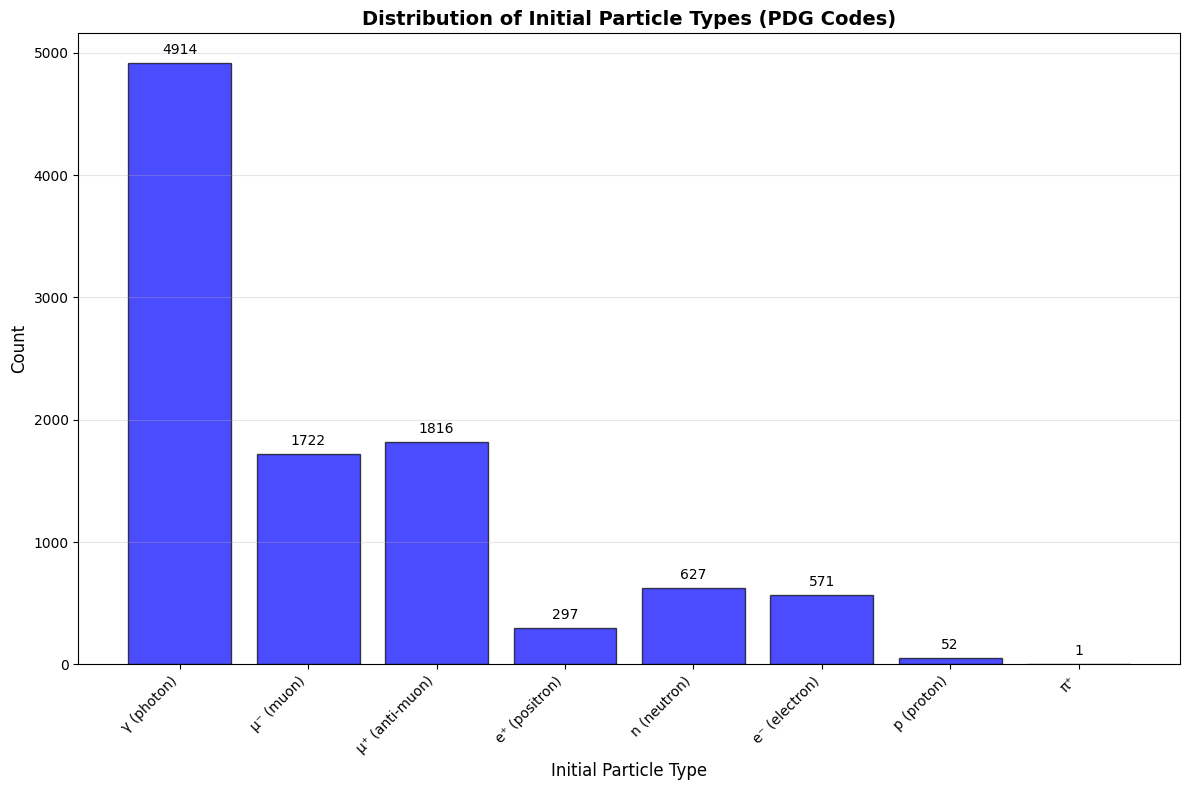

Total events: 10000
Number of different particle types: 8

Particle type breakdown:
  γ (photon): 4914 events (49.1%)
  μ⁺ (anti-muon): 1816 events (18.2%)
  μ⁻ (muon): 1722 events (17.2%)
  n (neutron): 627 events (6.3%)
  e⁻ (electron): 571 events (5.7%)
  e⁺ (positron): 297 events (3.0%)
  p (proton): 52 events (0.5%)
  π⁺: 1 events (0.0%)

Unique PDG codes found: [-13, -11, 11, 13, 22, 211, 2112, 2212]


In [29]:
# Plot a histogram of particle type sourceParticlePDG from event_data
source_particle_ids = event_data["sourceParticlePDG"].array()

import collections

# Count occurrences of each PDG code
counter = collections.Counter(source_particle_ids)

# PDG code to particle name mapping
pdg_labels = {
    11: "e⁻ (electron)",
    -11: "e⁺ (positron)", 
    13: "μ⁻ (muon)",
    -13: "μ⁺ (anti-muon)",
    22: "γ (photon)",
    2212: "p (proton)",
    2112: "n (neutron)",
    211: "π⁺",
    -211: "π⁻", 
    111: "π⁰",
    321: "K⁺",
    -321: "K⁻",
    0: "unknown"
}

# Prepare data for plotting
codes = list(counter.keys())
counts = [counter[c] for c in codes]
labels = [pdg_labels.get(c, f"PDG:{c}") for c in codes]

# Create the plot
plt.figure(figsize=(12, 8))
bars = plt.bar(range(len(labels)), counts, alpha=0.7, edgecolor='black', color='blue')

# Customize the plot
plt.xlabel("Initial Particle Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of Initial Particle Types (PDG Codes)", fontsize=14, fontweight='bold')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')

# Add count labels on bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
            str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Print summary statistics
print(f"Total events: {sum(counts)}")
print(f"Number of different particle types: {len(counter)}")
print("\nParticle type breakdown:")
for code, count in sorted(counter.items(), key=lambda x: x[1], reverse=True):
    particle_name = pdg_labels.get(code, f"PDG:{code}")
    percentage = (count / sum(counts)) * 100
    print(f"  {particle_name}: {count} events ({percentage:.1f}%)")

print(f"\nUnique PDG codes found: {sorted(codes)}")

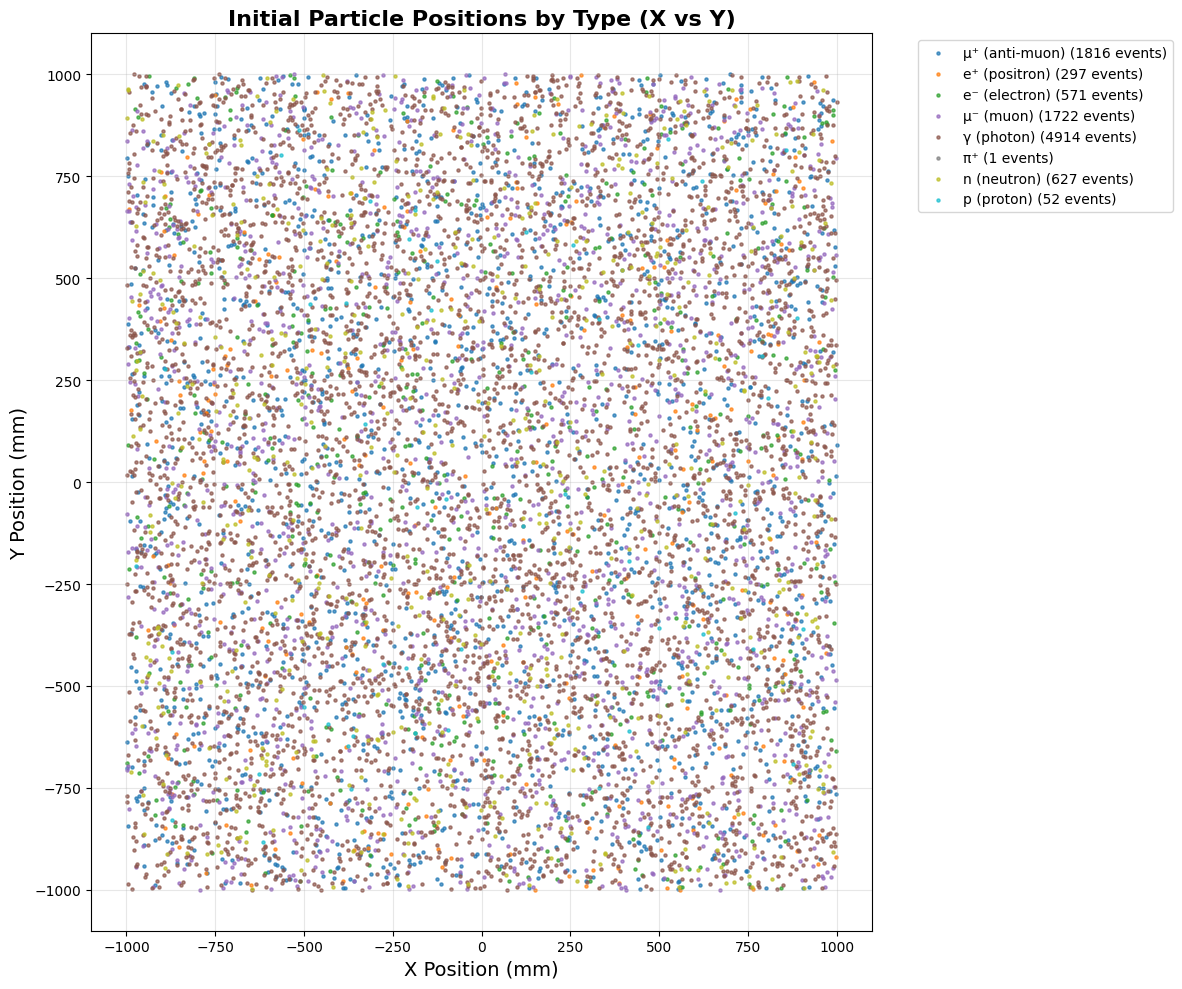

Initial Position Statistics:
X position range: -999.65 to 999.99 mm
Y position range: -999.95 to 1000.00 mm
Z position range: 4836.08 to 4836.08 mm

Radial distance from center: mean = 765.35 mm, max = 1401.68 mm

Total events plotted: 10000
Particle types: 8


In [30]:
# Plot the distribution of initial positions x, y in position0 with different colors for particle types

# Extract x, y, z coordinates from position0 data
position0 = event_data["position0"].array()
position0_arr = np.array([[vec.fX, vec.fY, vec.fZ] for vec in position0])

x_positions = position0_arr[:, 0]  # X coordinates
y_positions = position0_arr[:, 1]  # Y coordinates
z_positions = position0_arr[:, 2]  # Z coordinates

# Get particle types for color coding
source_particle_ids = event_data["sourceParticlePDG"].array()

# Create a single 2D scatter plot colored by particle type
plt.figure(figsize=(12, 10))

# Get unique particle types and assign colors
unique_pdg = np.unique(source_particle_ids)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_pdg)))

# PDG code to particle name mapping
pdg_labels = {
    11: "e⁻ (electron)",
    -11: "e⁺ (positron)", 
    13: "μ⁻ (muon)",
    -13: "μ⁺ (anti-muon)",
    22: "γ (photon)",
    2212: "p (proton)",
    2112: "n (neutron)",
    211: "π⁺",
    -211: "π⁻", 
    111: "π⁰",
    321: "K⁺",
    -321: "K⁻",
    0: "unknown"
}

# Plot each particle type with different color
for i, pdg_code in enumerate(unique_pdg):
    mask = source_particle_ids == pdg_code
    particle_name = pdg_labels.get(pdg_code, f"PDG:{pdg_code}")
    
    plt.scatter(x_positions[mask], y_positions[mask], 
               alpha=0.7, s=5, c=[colors[i]], 
               label=f"{particle_name} ({np.sum(mask)} events)")

plt.xlabel('X Position (mm)', fontsize=14)
plt.ylabel('Y Position (mm)', fontsize=14)
plt.title('Initial Particle Positions by Type (X vs Y)', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print position statistics
print("Initial Position Statistics:")
print(f"X position range: {x_positions.min():.2f} to {x_positions.max():.2f} mm")
print(f"Y position range: {y_positions.min():.2f} to {y_positions.max():.2f} mm")
print(f"Z position range: {z_positions.min():.2f} to {z_positions.max():.2f} mm")

# Calculate radial distribution for cosmic ray analysis
radial_distance = np.sqrt(x_positions**2 + y_positions**2)
print(f"\nRadial distance from center: mean = {radial_distance.mean():.2f} mm, max = {radial_distance.max():.2f} mm")

print(f"\nTotal events plotted: {len(x_positions)}")
print(f"Particle types: {len(unique_pdg)}")

In [31]:
# Analyze secondary particles in PMT hits
# The hits contain information about particles that actually reached the detectors

# Check what particle information is available in the hit data
print("Checking PMT hit data for secondary particle information...")

# Look at PMT hits structure
pmtHits = event_data["pmtHits"]
print("PMT hits branches:")
for key in pmtHits.keys():
    print(f"  {key}")

# Note: Currently we don't store particle type info in hits, only for primary particles
# The hits mainly contain optical photons that reached PMTs

# Let's see what we can learn from the hit timing and energy
try:
    # Get PMT hit data
    pmt_hit_times = pmtHits["pmtHits.eventTime"].array()
    pmt_hit_energies = pmtHits["pmtHits.photonEnergy"].array() 
    pmt_numbers = pmtHits["pmtHits.pmtNum"].array()
    
    # Flatten the arrays (since they're jagged - different hits per event)
    all_times = np.concatenate([times for times in pmt_hit_times if len(times) > 0])
    all_energies = np.concatenate([energies for energies in pmt_hit_energies if len(energies) > 0])
    all_pmts = np.concatenate([pmts for pmts in pmt_numbers if len(pmts) > 0])
    
    print(f"\nPMT Hit Analysis:")
    print(f"Total PMT hits: {len(all_times)}")
    print(f"Hit time range: {all_times.min():.2f} to {all_times.max():.2f} ns")
    print(f"Hit energy range: {all_energies.min():.4f} to {all_energies.max():.4f} eV")
    print(f"PMTs with hits: {len(np.unique(all_pmts))}")
    
    # Plot timing distribution (can reveal secondary particle production)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(all_times, bins=50, alpha=0.7, edgecolor='black')
    plt.xlabel('Hit Time (ns)')
    plt.ylabel('Count')
    plt.title('PMT Hit Timing Distribution')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.hist(all_energies, bins=50, alpha=0.7, edgecolor='black')
    plt.xlabel('Photon Energy (eV)')
    plt.ylabel('Count')
    plt.title('PMT Hit Energy Distribution')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Error analyzing PMT hits: {e}")


Checking PMT hit data for secondary particle information...
PMT hits branches:
  pmtHits.fUniqueID
  pmtHits.fBits
  pmtHits.pmtNum
  pmtHits.eventTime
  pmtHits.photonEnergy
  pmtHits.parentType

PMT Hit Analysis:
Total PMT hits: 14868
Error analyzing PMT hits: no field named 'min'


['eventData', 'eventData/TObject', 'eventData/TObject/fUniqueID', 'eventData/TObject/fBits', 'eventData/eventNumber', 'eventData/direction0', 'eventData/position0', 'eventData/vol0', 'eventData/sourceParticleEnergy', 'eventData/sourceParticlePDG', 'eventData/numHits', 'eventData/numHitsArea', 'eventData/muVetoEnergy[12]', 'eventData/pmtHits', 'eventData/pmtHits/pmtHits.fUniqueID', 'eventData/pmtHits/pmtHits.fBits', 'eventData/pmtHits/pmtHits.pmtNum', 'eventData/pmtHits/pmtHits.eventTime', 'eventData/pmtHits/pmtHits.photonEnergy', 'eventData/pmtHits/pmtHits.parentType', 'eventData/areaPMTHits', 'eventData/areaPMTHits/areaPMTHits.fUniqueID', 'eventData/areaPMTHits/areaPMTHits.fBits', 'eventData/areaPMTHits/areaPMTHits.pmtNum', 'eventData/areaPMTHits/areaPMTHits.eventTime', 'eventData/areaPMTHits/areaPMTHits.photonEnergy', 'eventData/areaPMTHits/areaPMTHits.parentType', 'eventData/areaPMTHits/areaPMTHits.photonPosition']
['TObject', 'TObject/fUniqueID', 'TObject/fBits', 'eventNumber', 'di

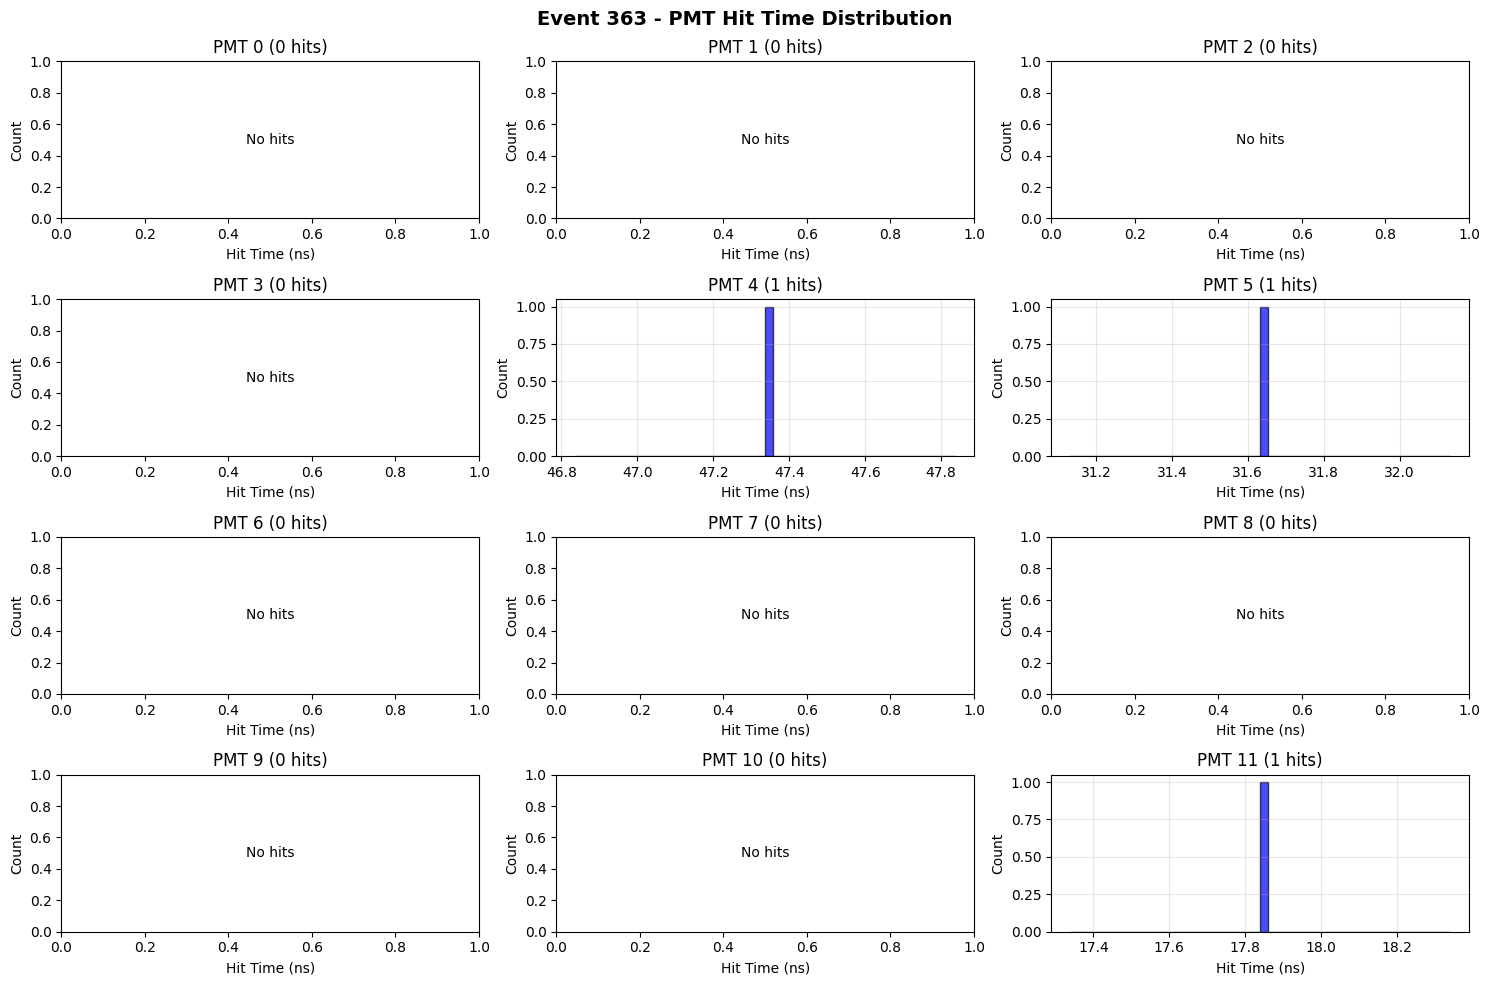

  Time range: 17.84 - 47.34 ns
  Energy range: 0.0000 - 0.0000 eV
  PMTs triggered: 3/12

Event 418 (#2 with hits):
  Total hits: 13
  Hit distribution across 12 PMTs:
    PMT 0: 2 hits
    PMT 1: 2 hits
    PMT 2: 1 hits
    PMT 6: 3 hits
    PMT 7: 2 hits
    PMT 8: 1 hits
    PMT 10: 1 hits
    PMT 11: 1 hits


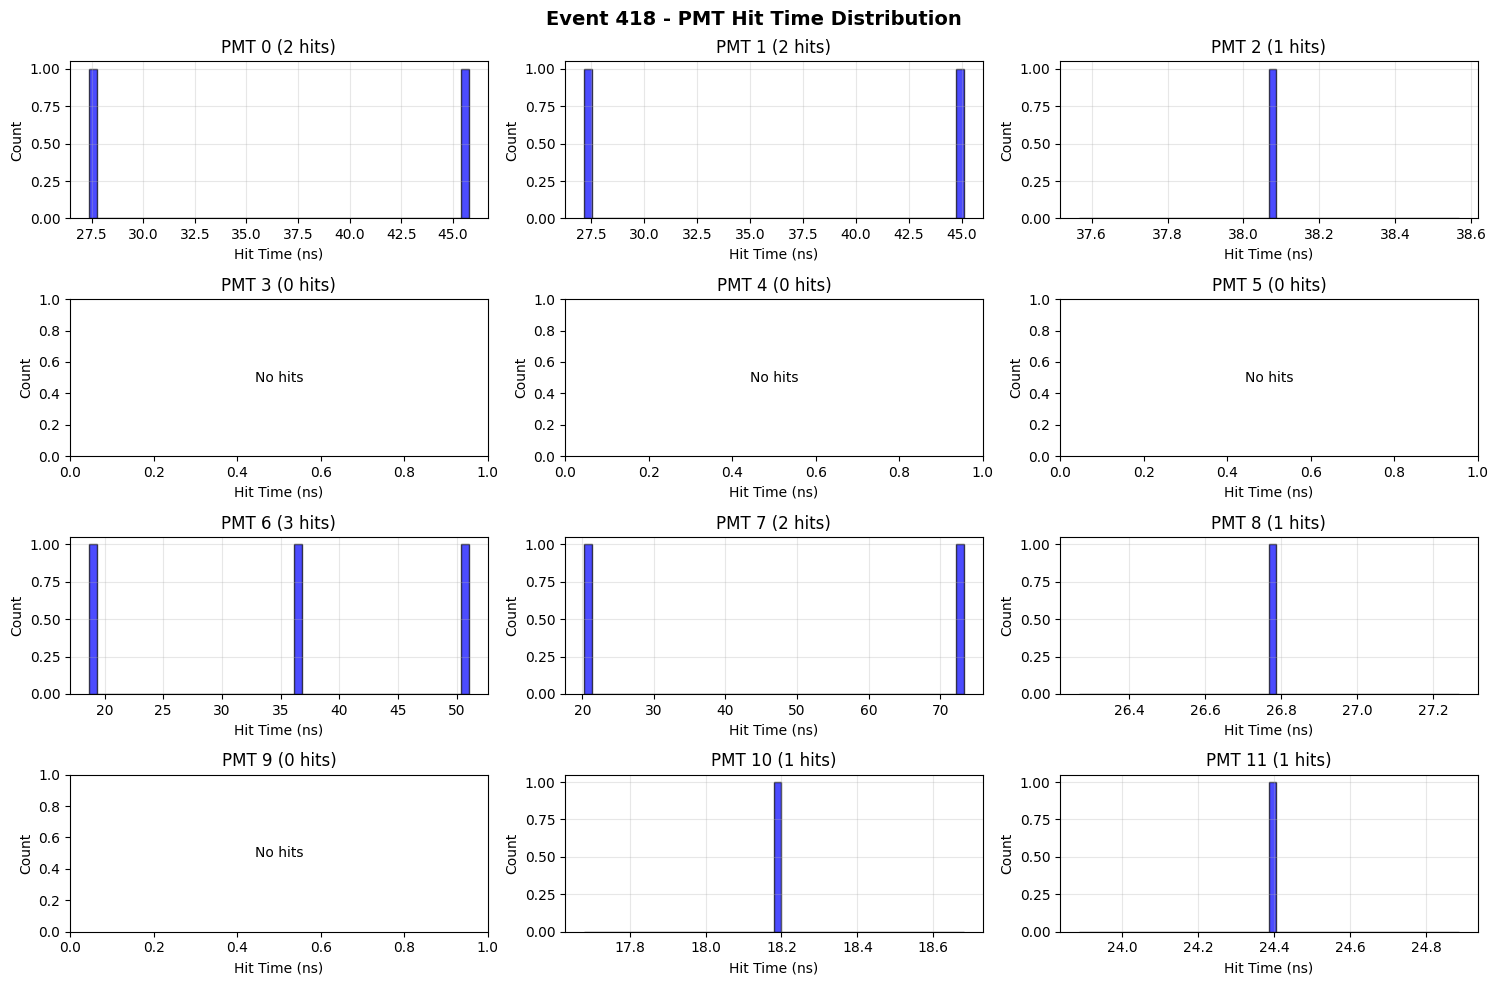

  Time range: 18.18 - 73.29 ns
  Energy range: 0.0000 - 0.0000 eV
  PMTs triggered: 8/12

Event 510 (#3 with hits):
  Total hits: 5
  Hit distribution across 12 PMTs:
    PMT 0: 2 hits
    PMT 4: 1 hits
    PMT 5: 1 hits
    PMT 8: 1 hits


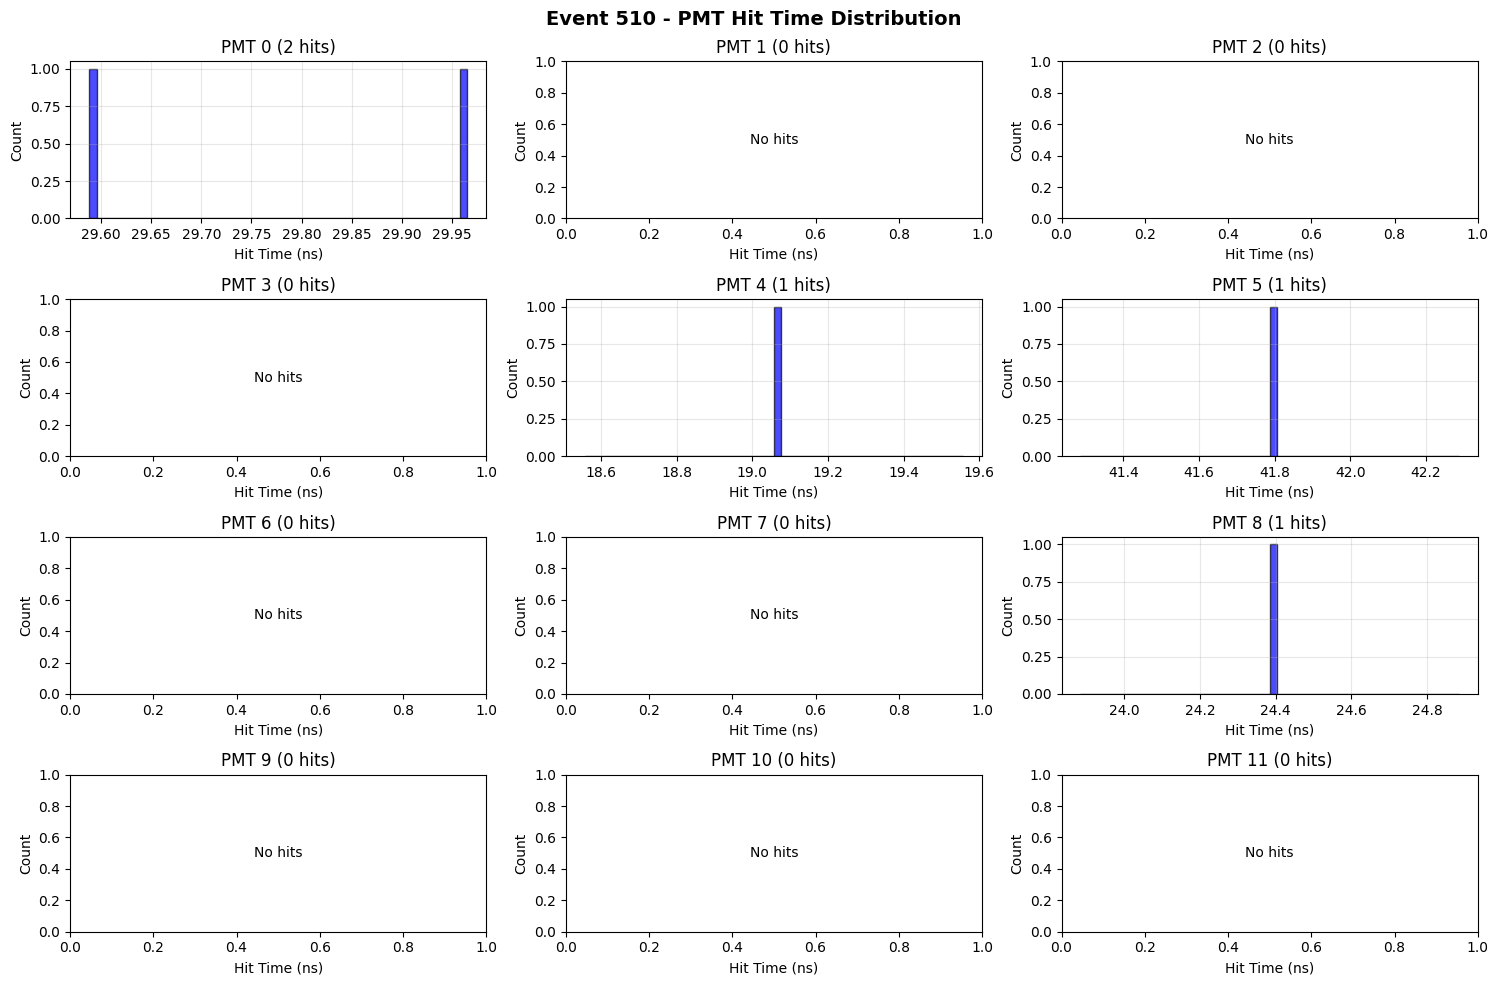

  Time range: 19.06 - 41.79 ns
  Energy range: 0.0000 - 0.0000 eV
  PMTs triggered: 4/12

Event 588 (#4 with hits):
  Total hits: 3
  Hit distribution across 12 PMTs:
    PMT 2: 1 hits
    PMT 3: 1 hits
    PMT 5: 1 hits


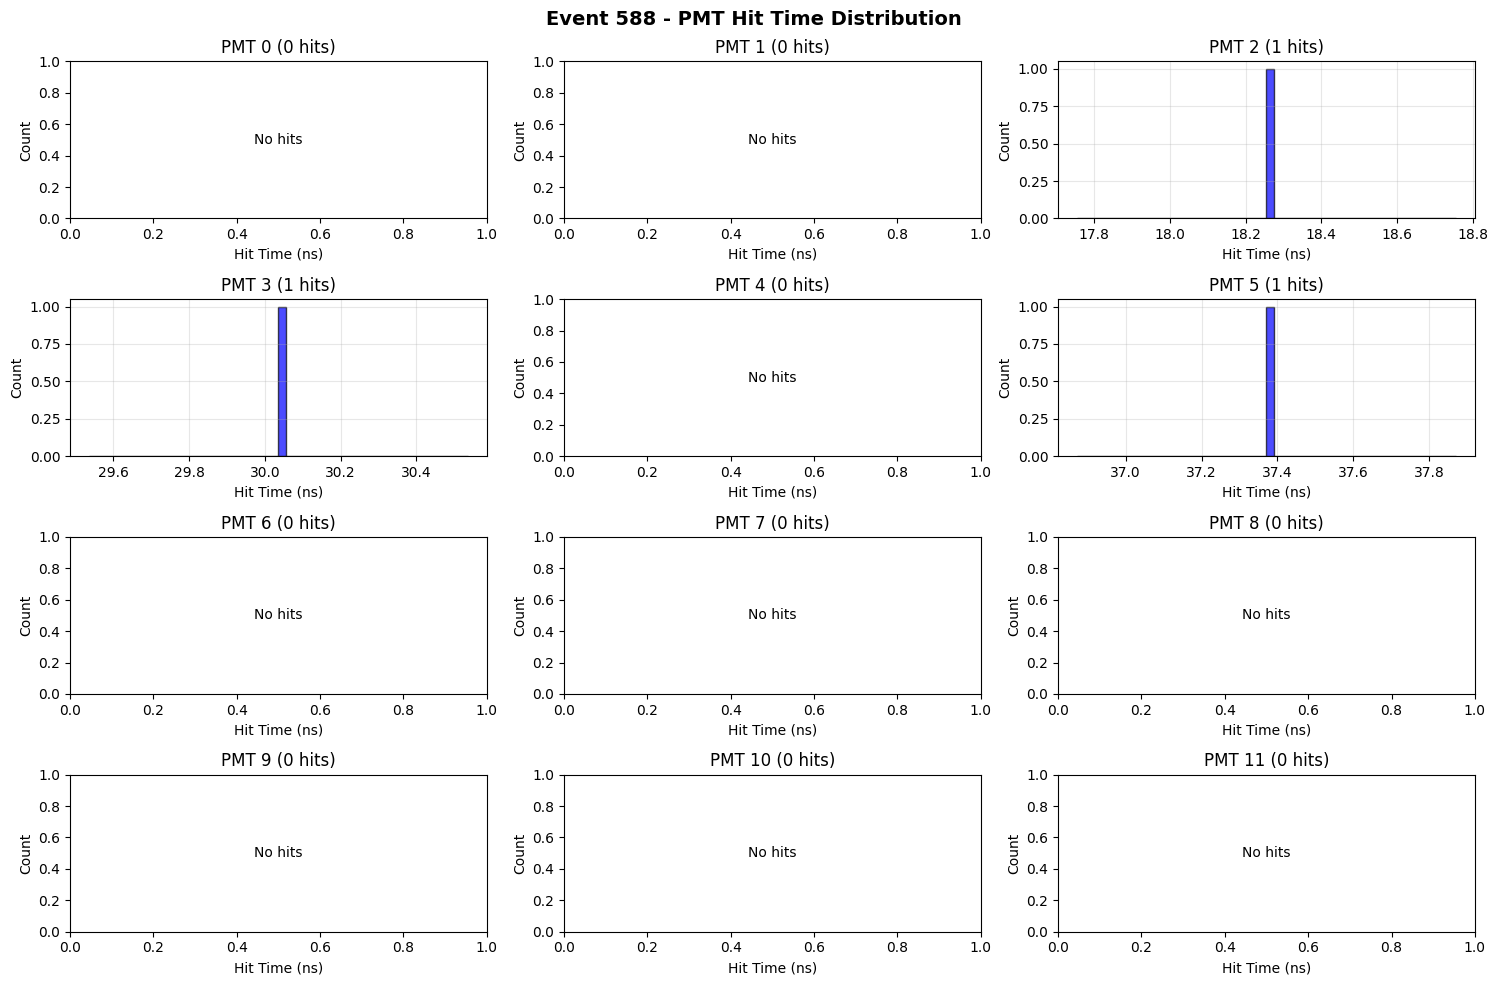

  Time range: 18.26 - 37.37 ns
  Energy range: 0.0000 - 0.0000 eV
  PMTs triggered: 3/12

Event 751 (#5 with hits):
  Total hits: 2740
  Hit distribution across 12 PMTs:
    PMT 0: 224 hits
    PMT 1: 247 hits
    PMT 2: 285 hits
    PMT 3: 155 hits
    PMT 4: 244 hits
    PMT 5: 255 hits
    PMT 6: 287 hits
    PMT 7: 226 hits
    PMT 8: 164 hits
    PMT 9: 258 hits
    PMT 10: 156 hits
    PMT 11: 239 hits


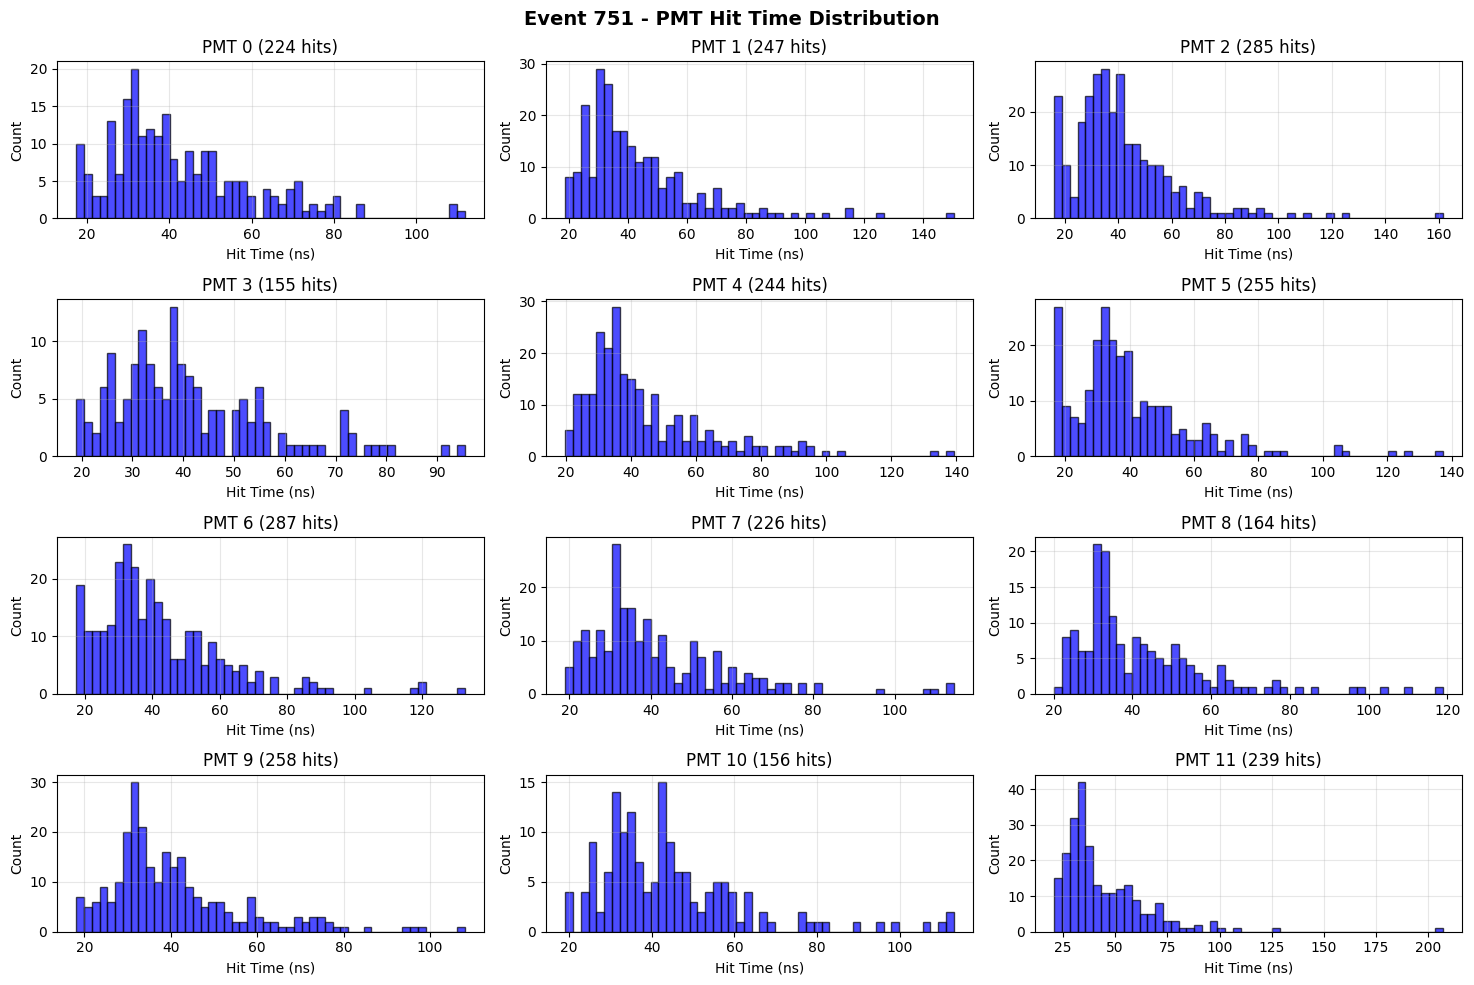

  Time range: 15.95 - 206.84 ns
  Energy range: 0.0000 - 0.0000 eV
  PMTs triggered: 12/12


In [32]:
import numpy as np
import matplotlib.pyplot as plt 
import uproot

#load Sim_D2ODetector013.root
# path = "/home/orn/g4d2o-topcylindricaldet/data/Sim_D2ODetector013.root"


Sim_Tree = file["Sim_Tree"]
# Check the branches in the tree
print(Sim_Tree.keys())
event_data = Sim_Tree["eventData"]
print(event_data.keys())

# PMT signal analysis - find and display 5 events with actual PMT hits
pmtHits = event_data["pmtHits"]
print("PMT hits branches:")
for key in pmtHits.keys():
    print(f"  {key}")

# Get PMT hit data arrays
pmt_hit_times = pmtHits["pmtHits.eventTime"].array()
pmt_hit_energies = pmtHits["pmtHits.photonEnergy"].array()
pmt_numbers = pmtHits["pmtHits.pmtNum"].array()

num_pmts = 12
total_events = len(pmt_hit_times)

print(f"\n{'='*80}")
print(f"PMT Signal Analysis")
print(f"{'='*80}\n")

# First, find events with actual hits
events_with_hits = []
for event_idx in range(total_events):
    if len(pmt_hit_times[event_idx]) > 0:
        events_with_hits.append(event_idx)

print(f"Total events in dataset: {total_events}")
print(f"Events with PMT hits: {len(events_with_hits)}")
print(f"Events without hits: {total_events - len(events_with_hits)}")

if len(events_with_hits) == 0:
    print("\n⚠️  WARNING: No events with PMT hits found in this dataset!")
    print("This could mean:")
    print("  - Particles didn't reach the PMTs")
    print("  - No optical photons were generated")
    print("  - PMT detection efficiency is very low")
    print("  - There may be an issue with the simulation")
else:
    print(f"\nFirst few events with hits: {events_with_hits[:10]}")
    
    # Plot up to first 5 events that have hits
    num_events_to_plot = min(5, len(events_with_hits))
    print(f"\nPlotting first {num_events_to_plot} events with PMT hits...\n")
    
    for i, event_idx in enumerate(events_with_hits[:num_events_to_plot]):
        times = pmt_hit_times[event_idx]
        energies = pmt_hit_energies[event_idx]
        pmts = pmt_numbers[event_idx]
        
        print(f"\nEvent {event_idx} (#{i+1} with hits):")
        print(f"  Total hits: {len(times)}")
        
        # Count hits per PMT channel
        pmt_hit_counts = {i: 0 for i in range(num_pmts)}
        for pmt_num in pmts:
            if pmt_num < num_pmts:
                pmt_hit_counts[pmt_num] += 1
        
        print(f"  Hit distribution across {num_pmts} PMTs:")
        for pmt_idx in range(num_pmts):
            count = pmt_hit_counts[pmt_idx]
            if count > 0:
                print(f"    PMT {pmt_idx}: {count} hits")
        
        # Plot timing histogram for each PMT
        plt.figure(figsize=(15, 10))
        for pmt_idx in range(num_pmts):
            plt.subplot(4, 3, pmt_idx + 1)
            
            # Get times for this specific PMT
            mask = pmts == pmt_idx
            pmt_times = times[mask]
            pmt_energies = energies[mask]
            
            if len(pmt_times) > 0:
                # Create histogram of hit times
                plt.hist(pmt_times, bins=50, alpha=0.7, color='blue', edgecolor='black')
                plt.title(f'PMT {pmt_idx} ({len(pmt_times)} hits)')
                plt.xlabel('Hit Time (ns)')
                plt.ylabel('Count')
                plt.grid(True, alpha=0.3)
            else:
                plt.text(0.5, 0.5, 'No hits', ha='center', va='center', transform=plt.gca().transAxes)
                plt.title(f'PMT {pmt_idx} (0 hits)')
                plt.xlabel('Hit Time (ns)')
                plt.ylabel('Count')
        
        plt.suptitle(f'Event {event_idx} - PMT Hit Time Distribution', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Summary statistics
        print(f"  Time range: {np.min(times):.2f} - {np.max(times):.2f} ns")
        print(f"  Energy range: {np.min(energies):.4f} - {np.max(energies):.4f} eV")
        print(f"  PMTs triggered: {len(np.unique(pmts))}/{num_pmts}")